In [215]:
import matplotlib.pyplot as plt
import numpy as np
import rioxarray as rio
import shapely
import skimage
import geopandas as gpd
# I utilized GitHub's built-in LLM to assist in this assignment.

In [216]:
asheville = rio.open_rasterio(r"C:\Users\asanders\Documents\AES408\Homework4\m_3508228_nw_17_060_20220923.tif").rio.reproject("EPSG:4326")
print(asheville)

<xarray.DataArray (band: 4, y: 11395, x: 11676)> Size: 532MB
array([[[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        ...,
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 255]],

       [[255, 255, 255, ..., 255, 255, 255],
        [255, 255, 255, ..., 255, 255, 

Text(0.5, 1.0, 'Asheville, North Carolina')

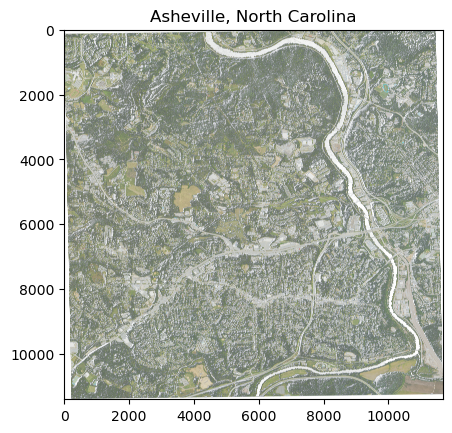

In [217]:
plt.imshow(asheville.transpose('y', 'x', 'band').values)
plt.title("Asheville, North Carolina")

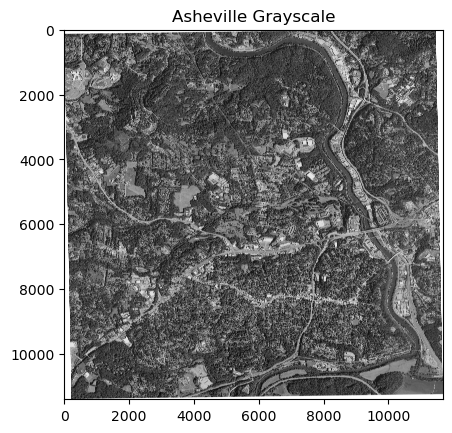

In [218]:
from skimage.color import rgb2gray
image = asheville.transpose('y','x','band')
rgb = image[:, :, :3] # this line removes nir from the image and leaves only the red, green, and blue bands; this is because the rgb2gray function only works with 3 bands
asheville_grayscale = rgb2gray(rgb)
plt.imshow(asheville_grayscale, cmap='gray')
plt.title("Asheville Grayscale")
plt.show()

Text(0.5, 1.0, 'Asheville After Applying Entropy')

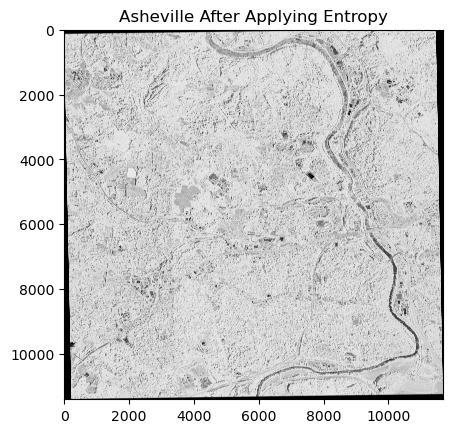

In [255]:
from skimage.filters.rank import entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte # img_as_ubyte converts the image to an 8-bit integer format, which--from what I read in the scikit-image documentation--greatly assists the entropy function
asheville_grayscale_ubyte = img_as_ubyte(asheville_grayscale)
asheville_entropy = entropy((asheville_grayscale_ubyte), disk(3))
plt.imshow(asheville_entropy, cmap='gray')
plt.title("Asheville After Applying Entropy")

C:\Users\asanders\AppData\Local\Temp\ipykernel_15436\1135862665.py:4: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  buildings_v3 = remove_small_objects(buildings_v2, min_size=200)


Text(0.5, 1.0, 'Applied Remove_Small_Objects and Opening')

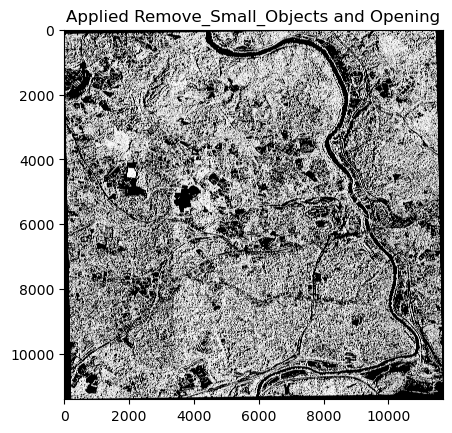

In [256]:
from skimage.morphology import remove_small_objects, opening
buildings = asheville_entropy > 4 # From what I understand after googling, entropy values above 4 are likely to be buildings because they can be distinguished from vegetation due to variations in pixels.
buildings_v2 = opening(buildings, disk(2)) # Opening removes bright spots that are likely to be noise.
buildings_v3 = remove_small_objects(buildings_v2, min_size=200)
plt.imshow(buildings_v3, cmap='gray')
plt.title("Applied Remove_Small_Objects and Opening")

In [257]:
# Creating the shapefile
from rasterio.features import shapes # converts raster pixels to vector shapes
from shapely.geometry import shape # transforms geometry objects into shapely objects
convert_to_integers = buildings_v3.astype(np.uint8) # .astype(np.uint8) changes my image into integers, where 1 is true (building) and 0 is false (not a building)
transformation = asheville.rio.transform()

asheville_building_polygons = [
    shape(geom)
    for geom, value in shapes(convert_to_integers, transform=transformation)
    if value == 1
] # makes a list of shapely geometry objects for the buildings in the image by looping through the shapes and only keeping those that are labeled as 1 (so, a building)

In [258]:
asheville_gdf = gpd.GeoDataFrame(geometry=asheville_building_polygons, crs=asheville.rio.crs)
asheville_gdf.to_file("asheville_buildings.shp")